# Autoregressive image models

The other notebooks in this folder learn a distribution by *transporting* noise into data —
a diffusion or flow ODE. An autoregressive model does something different and much more
literal: it factorises the image exactly,

$$p(x) = \prod_{t} p(x_t \mid x_{<t}),$$

and learns each conditional with a causal transformer over the pixels read in raster order.

The trade is clean. Training is one forward pass and an exact likelihood — no ELBO, no
score matching, nothing to approximate. Sampling costs one forward pass **per pixel**,
which is why this family lost to diffusion for large images and still wins whenever you
actually need the likelihood.

MNIST is downsampled to 14×14 and binarized so the whole notebook runs on a CPU in a few
minutes. `examples/nn/images/ar_transformer.py` is the same model at full 28×28 with
256-way pixel values and multi-device training.

In [1]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from datasets import disable_progress_bars, load_dataset
from flax import nnx

from probjax.nn import ARFamily, Autoregressive, TransformerARConditionerConfig
from probjax.nn.layers.attention import dot_product_attention

SIDE = 14
NUM_PIXELS = SIDE * SIDE

disable_progress_bars()
# datasets>=5 / huggingface_hub>=1 require the namespaced repo id.
mnist = load_dataset("ylecun/mnist", keep_in_memory=True)
mnist.set_format(type="numpy", columns=["image"])

images = np.asarray(mnist["train"]["image"], dtype=np.float32) / 255.0
images = images.reshape(-1, SIDE, 2, SIDE, 2).mean(axis=(2, 4))  # 28x28 -> 14x14
data = jnp.asarray((images > 0.5).astype(np.int32).reshape(-1, NUM_PIXELS))

print("data:", data.shape, f"({float(data.mean()):.1%} of pixels are on)")

data: (60000, 196) (12.7% of pixels are on)


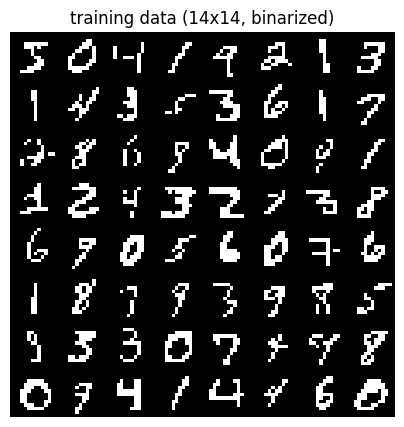

In [2]:
def show_grid(sequences, title, rows=8, cols=8):
    grid = np.asarray(sequences[: rows * cols]).reshape(rows, cols, SIDE, SIDE)
    grid = grid.transpose(0, 2, 1, 3).reshape(rows * SIDE, cols * SIDE)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


show_grid(data, "training data (14x14, binarized)")

## The model

One library call builds the decoder from `examples/nn/nets/transformer.ipynb`,
specialized to 196 pixel tokens:

- pixels are **tokens** with a categorical head (off/on per position);
- a causal transformer conditioner predicts each position's distribution
  from the pixels before it;
- shifting the input right by one (with a learned begin-of-sequence token)
  plus a causal mask is what stops position *t* from seeing anything after
  it. The library does this internally, so the data stays plain 0/1 with
  no extra symbol.

`dot_product_attention` is exact softmax without a fused kernel: the same
math as the `flex_attention` production path (see `ar_transformer.py` below),
but fast on a CPU. Get the shift-or-mask wrong and the loss drops beautifully
while the model learns nothing — it is copying.

In [3]:
model = Autoregressive(
    NUM_PIXELS,
    ARFamily.categorical(2),
    nnx.Rngs(0),
    conditioner=TransformerARConditionerConfig(
        num_layers=2,
        num_heads=4,
        model_dim=64,
        attn_size=16,
        attention_fn=dot_product_attention,
    ),
)
params = sum(p.size for _, p in nnx.to_flat_state(nnx.state(model, nnx.Param)))
print(f"{params:,} parameters")

67,264 parameters


## Training

The loss is plain cross entropy, and because the factorisation is exact it *is* the
negative log likelihood. Divide by $\log 2$ to read it as **bits per pixel** — the average
number of bits this model would need to store one pixel of an MNIST digit.

The comparison that makes the number mean something: a model that ignored the image
entirely and just used the marginal on-pixel rate would spend the pixel entropy, about
0.55 bits. Anything below that is structure the transformer found.
`model.fit` minimizes exactly this loss. It reports nats summed over the
whole image, so the cell below divides by pixels × log 2 to read bits/pixel.

`model.fit` minimizes exactly this loss. It reports nats summed over the
whole image, so the cell below divides by pixels × log 2 to read bits/pixel.


trained in 119s
model:    0.216 bits/pixel
marginal: 0.550 bits/pixel  <- ignoring all spatial structure


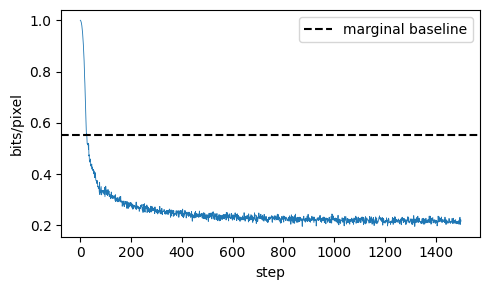

In [4]:
start = time.time()
losses = np.asarray(model.fit(jax.random.key(0), data, num_steps=1500, batch_size=64))

rate = float(data.mean())
baseline = -(rate * np.log2(rate) + (1 - rate) * np.log2(1 - rate))
bits = losses / (NUM_PIXELS * np.log(2))  # fit reports nats per image
print(f"trained in {time.time() - start:.0f}s")
print(f"model:    {bits[-100:].mean():.3f} bits/pixel")
print(f"marginal: {baseline:.3f} bits/pixel  <- ignoring all spatial structure")

plt.figure(figsize=(5, 3))
plt.plot(bits, lw=0.6)
plt.axhline(baseline, color="k", ls="--", label="marginal baseline")
plt.xlabel("step")
plt.ylabel("bits/pixel")
plt.legend()
plt.tight_layout()

## Sampling in three lines

Raster order, one pixel at a time: `vmap` over the keys generates the whole
batch in parallel — the *sequence* is serial, the batch is not.

The difference between the two calls below is where each step's prefix comes
from. The naive path re-reads the whole prefix through the transformer at
every step: $T$ full $T \times T$ attention matrices, about $T^3$ scores per
image. The cached path (`use_cache=True`, the default) keeps keys and values
and reads one growing row per step: about $T^2/2$ scores, ~400x less attention
work at 196 pixels. Same keys, so the same distribution — the cell checks
the draws agree up to the floating-point dust between the two compiled
scans.

Timing uses `block_until_ready`: JAX dispatches asynchronously, so bare
`time.time` differences only measure enqueueing, not execution.

draws identical: 100.0% (same keys; stragglers are float dust)
naive:  5.3s for 64 images (196 steps each)
cached: 0.4s for 64 images (196 steps each)
attention scores per image: naive ~7.5M, cached ~19K


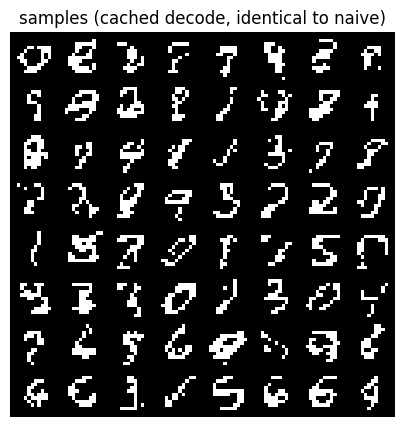

In [5]:
sample_key = jax.random.key(7)

# Warm up both compiled paths on a small batch, then time steady state.
_ = model.sample(sample_key, (2,), use_cache=False)
_ = model.sample(sample_key, (2,))

t0 = time.time()
samples_naive = model.sample(sample_key, (64,), use_cache=False)
samples_naive.block_until_ready()
t_naive = time.time() - t0

t0 = time.time()
samples = model.sample(sample_key, (64,))
samples.block_until_ready()
t_cached = time.time() - t0

agreement = float((samples == samples_naive).mean())
print(f"draws identical: {agreement:.1%} (same keys; stragglers are float dust)")
print(f"naive:  {t_naive:.1f}s for 64 images ({NUM_PIXELS} steps each)")
print(f"cached: {t_cached:.1f}s for 64 images ({NUM_PIXELS} steps each)")
print(
    f"attention scores per image: naive ~{NUM_PIXELS**3 / 1e6:.1f}M, "
    f"cached ~{NUM_PIXELS * (NUM_PIXELS + 1) // 2 / 1e3:.0f}K"
)
show_grid(samples, "samples (cached decode, identical to naive)")

Strokes, closed loops, roughly digit-shaped blobs — and plenty that are not digits. That
is a 2-layer, 64-wide model trained for 1500 steps on a laptop CPU, and the notebook is
sized for that rather than for pretty pictures. The method is not the limitation here.

### Completing a partial image

Because the factorisation is left-to-right, conditioning on a *prefix* is free — clamp the
first pixels to a real image and let the model finish the rest. No retraining, no guidance.
(Conditioning on an arbitrary *subset* is not free in this family; that is what
`simformer.ipynb` is for.)

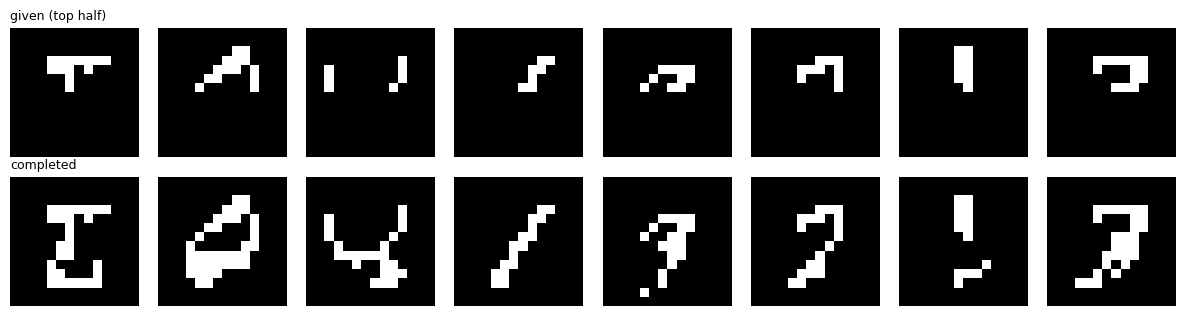

In [6]:
given = NUM_PIXELS // 2  # top half
originals = data[:8]
completions = model.sample(
    jax.random.key(3), (8,), prefix=originals, prefix_len=given
)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for col in range(8):
    masked = np.asarray(originals[col]).copy()
    masked[given:] = 0
    axes[0, col].imshow(masked.reshape(SIDE, SIDE), cmap="gray")
    axes[1, col].imshow(np.asarray(completions[col]).reshape(SIDE, SIDE), cmap="gray")
    for row in range(2):
        axes[row, col].axis("off")
axes[0, 0].set_title("given (top half)", loc="left", fontsize=9)
axes[1, 0].set_title("completed", loc="left", fontsize=9)
fig.tight_layout()

## Scaling up: `examples/nn/images/ar_transformer.py`

The same model at production settings, as a script rather than a notebook:

- full 28×28 resolution — 784 tokens instead of 196;
- **256-way categorical** pixel values instead of binary. Only two lines change,
  `nnx.Embed(257, dim)` and `nnx.Linear(dim, 256)`, plus `BOS = 256`; bits/dim is then
  reported over 256 levels and is directly comparable to the numbers in the literature;
- `flex_attention` with `CausalMask()` for the fused kernel (see
  `examples/nn/nets/attention.ipynb`);
- data augmentation, warmup + cosine decay, checkpointing, multi-device training.

```bash
python examples/nn/images/ar_transformer.py --num-steps 50000 --batch-size 128
```

## Where to go next

- `examples/nn/nets/transformer.ipynb` — the causal decoder in miniature.
- `simformer.ipynb` — conditioning on arbitrary subsets rather than prefixes.
- `diffusion.ipynb`, `flow_matching.ipynb` — the transport-based alternatives, which
  sample in tens of steps instead of one per dimension, but give up the exact likelihood.

## Swapping the conditioner: MLP and state space

Everything above used a transformer conditioner, but the model only needs a
causal map from tokens to per-dimension parameters. Two alternatives through
the same API:

- **MLP (MADE)**: the default `MLPARConditionerConfig` -- a masked MLP whose
  masks enforce the autoregressive property. No attention, no recurrence.
- **State space (LRU)**: a unidirectional recurrent stack. Causality comes
  from the recurrence itself: shift the tokens right, prepend a learned start
  token, and position `i` can only have seen `x_<i`.

Same data, same loss, same 1500 steps -- the comparison is apples to apples.

trained in 2s
MLP: 0.275 bits/pixel


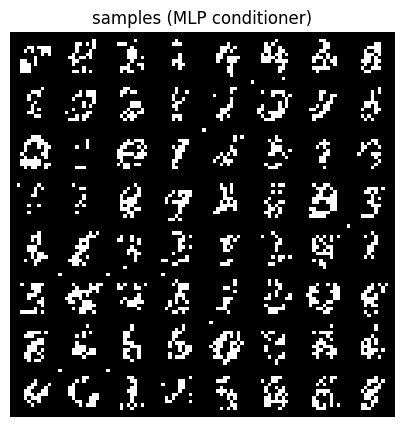

In [7]:
mlp_model = Autoregressive(
    NUM_PIXELS,
    ARFamily.categorical(2),
    nnx.Rngs(0),
    # conditioner omitted: MLPARConditionerConfig is the default.
)
start = time.time()
mlp_losses = np.asarray(mlp_model.fit(jax.random.key(0), data, num_steps=3500, batch_size=64))
mlp_bits = mlp_losses / (NUM_PIXELS * np.log(2))
print(f"trained in {time.time() - start:.0f}s")
print(f"MLP: {mlp_bits[-100:].mean():.3f} bits/pixel")
show_grid(mlp_model.sample(jax.random.key(7), (64,)), "samples (MLP conditioner)")

trained in 114s
SSM: 0.245 bits/pixel


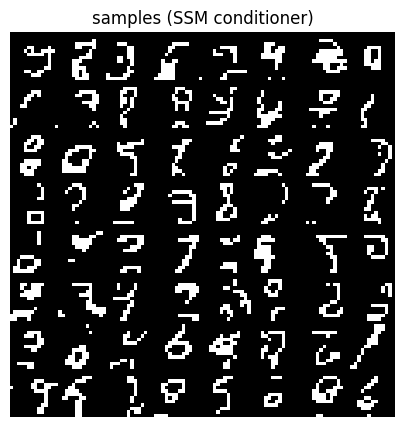

In [8]:
from probjax.nn import SSMARConditionerConfig


ssm_model = Autoregressive(
    NUM_PIXELS,
    ARFamily.categorical(2),
    nnx.Rngs(0),
    conditioner=SSMARConditionerConfig(),
)
start = time.time()
ssm_losses = np.asarray(ssm_model.fit(jax.random.key(0), data, num_steps=1500, batch_size=64))
ssm_bits = ssm_losses / (NUM_PIXELS * np.log(2))
print(f"trained in {time.time() - start:.0f}s")
print(f"SSM: {ssm_bits[-100:].mean():.3f} bits/pixel")
show_grid(ssm_model.sample(jax.random.key(7), (64,)), "samples (SSM conditioner)")